## Install Tabml package

In [1]:
import sys
import os

# Kaggle automatically unzips the archive
# Your files are available at /kaggle/input/your-dataset-name/
# Update this path based on your dataset name
TABML_PATH = '/kaggle/input/tabml-repo'

# Check what's available in the dataset
print("Contents of TabML dataset:")
!ls -la {TABML_PATH}

# First install required dependencies
print("\nInstalling TabML dependencies...")
!pip install -q loguru optuna

# Install TabNet for neural network models (optional but recommended)
!pip install -q pytorch-tabnet

# Add TabML to Python path
sys.path.insert(0, TABML_PATH)

# Import and verify
import tabml
print(f"\n✓ TabML version {tabml.__version__} loaded successfully!")

# Check available modules
from tabml import TabularPipeline, XGBoostModel, LightGBMModel
print("✓ Core modules imported successfully")

Contents of TabML dataset:
total 100
drwxr-xr-x 7 nobody nogroup     0 Aug 16 14:19 .
drwxr-xr-x 4 root   root     4096 Aug 16 14:37 ..
-rw-r--r-- 1 nobody nogroup  3113 Aug 16 14:19 ANALYSIS_GUIDE.md
-rw-r--r-- 1 nobody nogroup  1072 Aug 16 14:19 build_docs.sh
-rw-r--r-- 1 nobody nogroup  1871 Aug 16 14:19 CHANGELOG.md
drwxr-xr-x 3 nobody nogroup     0 Aug 16 14:19 data
drwxr-xr-x 3 nobody nogroup     0 Aug 16 14:19 docs
drwxr-xr-x 2 nobody nogroup     0 Aug 16 14:19 examples
-rw-r--r-- 1 nobody nogroup  1400 Aug 16 14:19 .gitignore
-rw-r--r-- 1 nobody nogroup  3754 Aug 16 14:19 install.sh
-rw-r--r-- 1 nobody nogroup  1074 Aug 16 14:19 LICENSE
-rw-r--r-- 1 nobody nogroup  1707 Aug 16 14:19 Makefile
-rw-r--r-- 1 nobody nogroup 10434 Aug 16 14:19 PRD.md
-rw-r--r-- 1 nobody nogroup   299 Aug 16 14:19 pytest.ini
-rw-r--r-- 1 nobody nogroup 15522 Aug 16 14:19 README.md
-rw-r--r-- 1 nobody nogroup   436 Aug 16 14:19 requirements-gpu.txt
-rw-r--r-- 1 nobody nogroup   709 Aug 16 14:19 require

2025-08-16 14:39:14.010 | INFO     | tabml._init_helpers:setup_nltk_data:21 - Downloading NLTK averaged_perceptron_tagger...
2025-08-16 14:39:17.067 | INFO     | tabml._init_helpers:check_gpu_availability:45 - GPU available: Tesla T4
2025-08-16 14:39:21.721 | INFO     | tabml._init_helpers:initialize_tabml:113 - TabML initialized successfully



✓ TabML version 0.2.0 loaded successfully!
✓ Core modules imported successfully


In [2]:
# Verify GPU availability (if using TabNet)
try:
    import torch
    if torch.cuda.is_available():
        print(f"✓ GPU available: {torch.cuda.get_device_name(0)}")
    else:
        print("✗ GPU not available, will use CPU")
except ImportError:
    print("PyTorch not installed")

# Check available models
from tabml import XGBoostModel, LightGBMModel, CatBoostModel
print("\n✓ Tree-based models available")

try:
    from tabml import TabNetModel
    print("✓ TabNet model available")
except ImportError:
    print("✗ TabNet not available (install pytorch-tabnet)")

✓ GPU available: Tesla T4

✓ Tree-based models available
✓ TabNet model available


## Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# TabML imports
from tabml import (
    DataLoader,
    FeatureEngineer,
    AdvancedFeatureEngineer,
    FeatureSelector,
    ModelTrainer,
    XGBoostModel,
    LightGBMModel,
    CatBoostModel,
    TabNetModel,
    VotingEnsemble,
    OOFEnsemble,
    AutoEnsemble,
    CrossValidator,
    Visualizer,
    DataValidator
)

# Standard imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

# Set paths for Kaggle
DATA_DIR = "/kaggle/input/spaceship-titanic"
OUTPUT_DIR = "/kaggle/working"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SUBMISSION_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /kaggle/input/spaceship-titanic
Output directory: /kaggle/working


## 1. Data Loading and Initial Exploration

In [4]:
def load_and_explore_data():
    """Load data and perform initial exploration."""
    print("="*70)
    print("1. LOADING DATA AND INITIAL EXPLORATION")
    print("="*70)
    
    # Load data
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    submission_df = pd.read_csv(SUBMISSION_PATH)
    
    print(f"\nTrain shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    print(f"Submission shape: {submission_df.shape}")
    
    # Basic info
    print("\nTrain Data Info:")
    print(train_df.info())
    
    print("\nFirst few rows:")
    print(train_df.head())
    
    print("\nTarget distribution:")
    print(train_df['Transported'].value_counts(normalize=True))
    
    print("\nMissing values in train:")
    missing = train_df.isnull().sum()
    missing_pct = 100 * missing / len(train_df)
    missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
    print(missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False))
    
    return train_df, test_df, submission_df

# Load the data
train_df, test_df, submission_df = load_and_explore_data()

1. LOADING DATA AND INITIAL EXPLORATION

Train shape: (8693, 14)
Test shape: (4277, 13)
Submission shape: (4277, 2)

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

Fi

## 2. Automated EDA with Visualizations


2. AUTOMATED EXPLORATORY DATA ANALYSIS


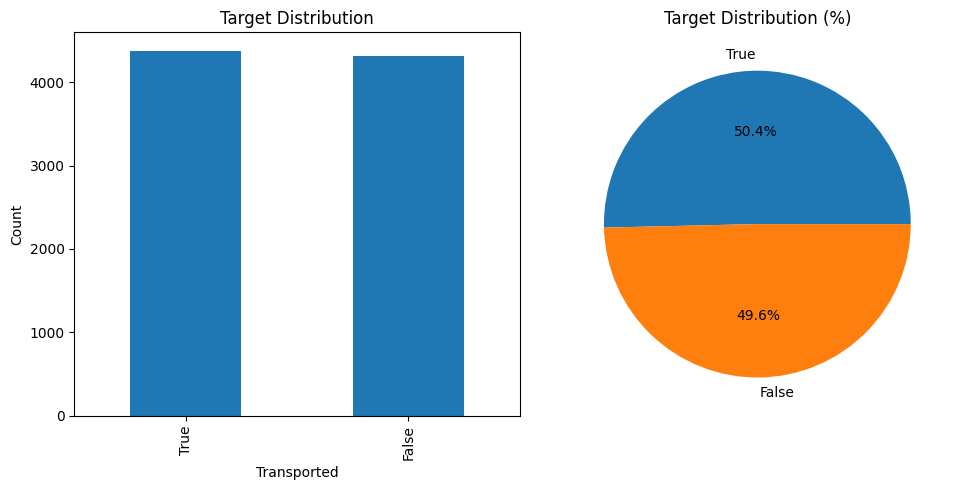

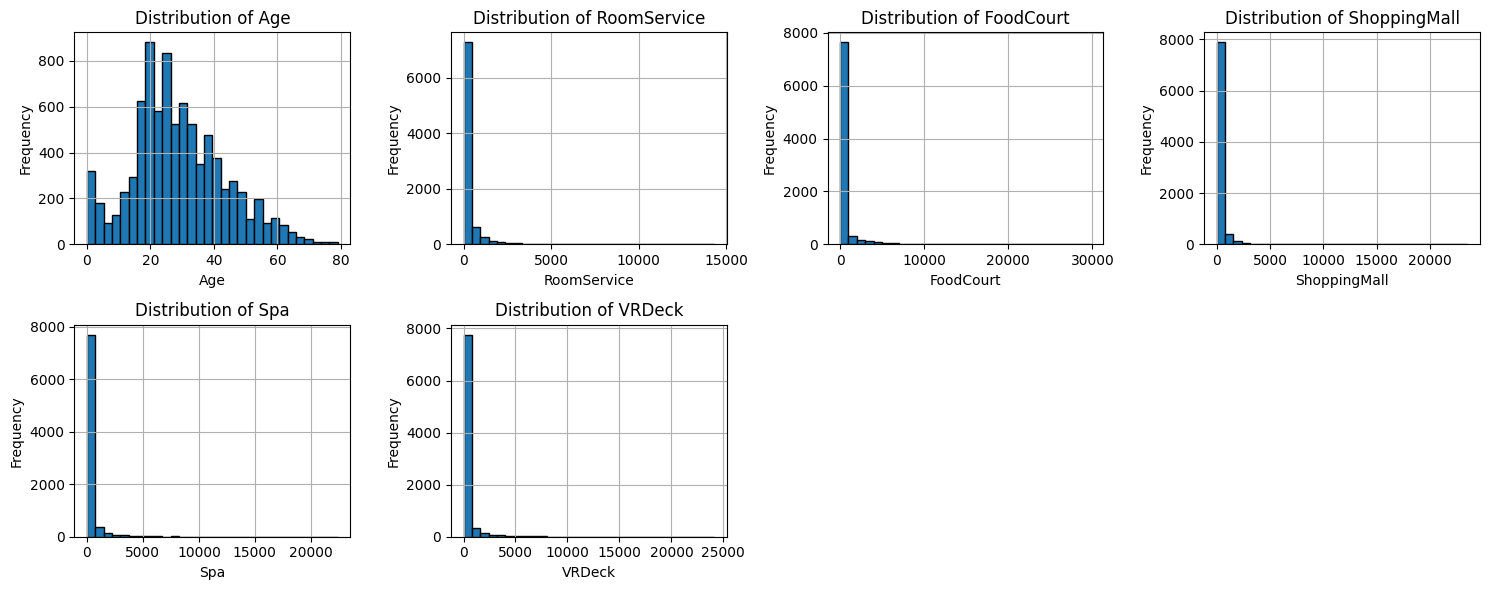

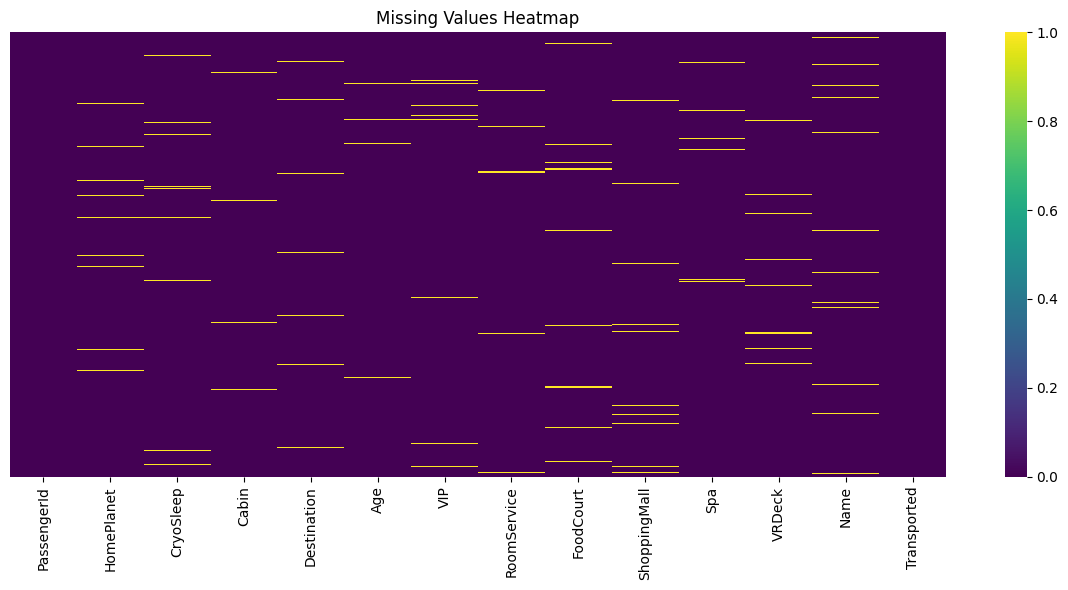

2025-08-16 14:39:29.908 | INFO     | tabml.validation:validate_data:157 - No data leakage detected.



EDA visualizations saved to /kaggle/working

Data Validation Results:
  - Missing values: False
  - Duplicates: False
  - High cardinality: []


In [5]:
def automated_eda(train_df, test_df=None):
    """Perform automated exploratory data analysis."""
    print("\n" + "="*70)
    print("2. AUTOMATED EXPLORATORY DATA ANALYSIS")
    print("="*70)
    
    # Create visualizer
    viz = Visualizer()
    
    # Set style
    plt.style.use('default')
    
    # 1. Target distribution
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    train_df['Transported'].value_counts().plot(kind='bar')
    plt.title('Target Distribution')
    plt.xlabel('Transported')
    plt.ylabel('Count')
    
    plt.subplot(1, 2, 2)
    train_df['Transported'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title('Target Distribution (%)')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'target_distribution.png'))
    plt.show()
    
    # 2. Numerical features distribution
    numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    if 'Transported' in numerical_cols:
        numerical_cols.remove('Transported')
    
    if len(numerical_cols) > 0:
        n_cols = min(4, len(numerical_cols))
        n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
        axes = axes.flatten() if n_rows > 1 else [axes]
        
        for idx, col in enumerate(numerical_cols):
            if idx < len(axes):
                train_df[col].hist(bins=30, ax=axes[idx], edgecolor='black')
                axes[idx].set_title(f'Distribution of {col}')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frequency')
        
        # Hide extra subplots
        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'numerical_distributions.png'))
        plt.show()
    
    # 3. Missing values heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(train_df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'missing_values_heatmap.png'))
    plt.show()
    
    print(f"\nEDA visualizations saved to {OUTPUT_DIR}")
    
    # Data validation
    validation_results = {}
    if test_df is not None:
        validator = DataValidator()
        validation_results = validator.validate_data(train_df, test_df)
        print("\nData Validation Results:")
        print(f"  - Missing values: {validation_results.get('has_missing', False)}")
        print(f"  - Duplicates: {validation_results.get('has_duplicates', False)}")
        print(f"  - High cardinality: {validation_results.get('high_cardinality_features', [])}")
    
    return validation_results

# Perform EDA
validation_results = automated_eda(train_df, test_df)

## 3. Feature Engineering

In [6]:
def feature_engineering(train_df, test_df):
    """Perform comprehensive feature engineering."""
    print("\n" + "="*70)
    print("3. FEATURE ENGINEERING")
    print("="*70)
    
    # Combine for consistent preprocessing
    train_df['is_train'] = 1
    test_df['is_train'] = 0
    
    # Store IDs and target
    train_ids = train_df['PassengerId']
    test_ids = test_df['PassengerId']
    y_train = train_df['Transported'].astype(int)
    
    # Combine data
    df = pd.concat([train_df, test_df], ignore_index=True)
    
    print(f"\nCombined shape: {df.shape}")
    
    # ==========================================
    # 3.1 Parse existing features
    # ==========================================
    print("\n3.1 Parsing existing features...")
    
    # Parse PassengerId to extract group info
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    df['GroupSize'] = df.groupby('Group')['PassengerId'].transform('count')
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)
    
    # Parse Cabin to extract deck, number, and side
    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else None)
    df['CabinNumber'] = df['Cabin'].apply(lambda x: int(x.split('/')[1]) if pd.notna(x) and len(x.split('/')) > 1 else None)
    df['Side'] = df['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) and len(x.split('/')) > 2 else None)
    
    # Parse Name to extract surname
    df['Surname'] = df['Name'].apply(lambda x: x.split(' ')[0] if pd.notna(x) else None)
    df['FamilySize'] = df.groupby('Surname')['PassengerId'].transform('count')
    
    # ==========================================
    # 3.2 Create new features
    # ==========================================
    print("\n3.2 Creating new features...")
    
    # Total spending across all amenities
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpending'] = df[spending_cols].sum(axis=1)
    df['AvgSpending'] = df[spending_cols].mean(axis=1)
    df['MaxSpending'] = df[spending_cols].max(axis=1)
    df['MinSpending'] = df[spending_cols].min(axis=1)
    df['SpendingStd'] = df[spending_cols].std(axis=1)
    
    # Number of amenities used
    df['AmenitiesUsed'] = (df[spending_cols] > 0).sum(axis=1)
    df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)
    
    # Spending patterns
    df['LuxurySpending'] = df['Spa'] + df['VRDeck']
    df['BasicSpending'] = df['RoomService'] + df['FoodCourt']
    df['LuxuryRatio'] = df['LuxurySpending'] / (df['TotalSpending'] + 1)
    
    # Age groups
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                            labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
    df['IsChild'] = (df['Age'] < 18).astype(int)
    df['IsSenior'] = (df['Age'] >= 60).astype(int)
    
    # Cabin features
    df['CabinNumberGroup'] = pd.cut(df['CabinNumber'], bins=10, labels=False)
    
    # Interaction features
    df['CryoVIP'] = ((df['CryoSleep'] == True) & (df['VIP'] == True)).astype(int)
    df['CryoSpending'] = df['CryoSleep'].astype(float) * df['TotalSpending']
    
    # Family/Group features
    df['GroupSpending'] = df.groupby('Group')['TotalSpending'].transform('mean')
    df['FamilySpending'] = df.groupby('Surname')['TotalSpending'].transform('mean')
    
    # ==========================================
    # 3.3 Handle missing values intelligently
    # ==========================================
    print("\n3.3 Handling missing values...")
    
    # For CryoSleep passengers, spending should be 0
    cryo_mask = df['CryoSleep'] == True
    for col in spending_cols:
        df.loc[cryo_mask & df[col].isna(), col] = 0
    
    # Fill other numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numerical_cols:
        if col not in ['is_train', 'Transported']:
            df[col].fillna(df[col].median(), inplace=True)
    
    # Fill categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown', inplace=True)
    
    # ==========================================
    # 3.4 Encode categorical variables
    # ==========================================
    print("\n3.4 Encoding categorical variables...")
    
    # Label encoding for ordinal features
    label_encoders = {}
    label_encode_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']
    
    for col in label_encode_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col + '_Encoded'] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
    
    # One-hot encoding for nominal features (selectively)
    onehot_cols = ['HomePlanet', 'Destination']
    df = pd.get_dummies(df, columns=onehot_cols, prefix=onehot_cols, drop_first=True)
    
    # Boolean to int
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    for col in bool_cols:
        df[col] = df[col].astype(int)
    
    # ==========================================
    # 3.5 Split back to train/test
    # ==========================================
    print("\n3.5 Splitting back to train/test...")
    
    train_df = df[df['is_train'] == 1].drop('is_train', axis=1)
    test_df = df[df['is_train'] == 0].drop('is_train', axis=1)
    
    # Drop columns not useful for modeling
    drop_cols = ['PassengerId', 'Name', 'Cabin', 'Transported', 'Group', 'Surname', 
                 'AgeGroup', 'Deck', 'Side']
    
    for col in drop_cols:
        if col in train_df.columns:
            train_df = train_df.drop(col, axis=1)
        if col in test_df.columns:
            test_df = test_df.drop(col, axis=1)
    
    print(f"\nFinal train shape: {train_df.shape}")
    print(f"Final test shape: {test_df.shape}")
    print(f"Features created: {list(train_df.columns)[:20]}...")
    
    return train_df, test_df, y_train, train_ids, test_ids

# Perform feature engineering
X_train, X_test, y_train, train_ids, test_ids = feature_engineering(train_df, test_df)


3. FEATURE ENGINEERING

Combined shape: (12970, 15)

3.1 Parsing existing features...

3.2 Creating new features...

3.3 Handling missing values...

3.4 Encoding categorical variables...

3.5 Splitting back to train/test...

Final train shape: (8693, 38)
Final test shape: (4277, 38)
Features created: ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'IsAlone', 'CabinNumber', 'FamilySize', 'TotalSpending', 'AvgSpending', 'MaxSpending', 'MinSpending', 'SpendingStd', 'AmenitiesUsed', 'NoSpending', 'LuxurySpending']...


## 4. Advanced Feature Engineering with TabML

In [7]:
def advanced_feature_engineering(train_df, test_df, y_train):
    """Apply TabML's advanced feature engineering."""
    print("\n" + "="*70)
    print("4. ADVANCED FEATURE ENGINEERING WITH TABML")
    print("="*70)
    
    # Initialize advanced feature engineer
    adv_engineer = AdvancedFeatureEngineer()
    
    # 1. Create polynomial features for top numerical columns
    print("\n4.1 Creating polynomial features...")
    numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Select top columns based on variance
    variances = train_df[numerical_cols].var()
    top_cols = variances.nlargest(5).index.tolist()
    
    train_df = adv_engineer.create_polynomial_features(train_df, numeric_columns=top_cols, degree=2)
    test_df = adv_engineer.create_polynomial_features(test_df, numeric_columns=top_cols, degree=2)
    
    # 2. Create interaction features
    print("\n4.2 Creating interaction features...")
    train_df = adv_engineer.create_interaction_features(train_df, numeric_columns=top_cols, max_interactions=20)
    test_df = adv_engineer.create_interaction_features(test_df, numeric_columns=top_cols, max_interactions=20)
    
    # 3. Feature selection
    print("\n4.3 Selecting best features...")
    from tabml import FeatureSelector
    
    selector = FeatureSelector(method='tree_based', n_features=100)
    
    # Fit on train data
    train_df_selected = selector.fit_transform(train_df, y_train)
    test_df_selected = selector.transform(test_df)
    
    print(f"\nSelected {train_df_selected.shape[1]} features from {train_df.shape[1]}")
    
    # Get feature importance
    importance_df = selector.get_feature_importance()
    print("\nTop 10 most important features:")
    print(importance_df.head(10))
    
    return train_df_selected, test_df_selected, selector

# Apply advanced feature engineering
X_train, X_test, selector = advanced_feature_engineering(X_train, X_test, y_train)

2025-08-16 14:39:30.385 | INFO     | tabml.advanced_features:create_polynomial_features:397 - Created polynomial features for 5 columns
2025-08-16 14:39:30.394 | INFO     | tabml.advanced_features:create_polynomial_features:397 - Created polynomial features for 5 columns
2025-08-16 14:39:30.408 | INFO     | tabml.advanced_features:create_interaction_features:362 - Created 20 interaction features
2025-08-16 14:39:30.419 | INFO     | tabml.advanced_features:create_interaction_features:362 - Created 20 interaction features



4. ADVANCED FEATURE ENGINEERING WITH TABML

4.1 Creating polynomial features...

4.2 Creating interaction features...

4.3 Selecting best features...

Selected 73 features from 73

Top 10 most important features:
                               feature     score
10                         CabinNumber  0.036553
54     TotalSpending_div_GroupSpending  0.032694
21                         LuxuryRatio  0.031780
1                                  Age  0.024832
28                      FamilySpending  0.024020
64  TotalSpending_minus_FamilySpending  0.023636
47                FamilySpending_pow_2  0.023602
48                 FamilySpending_sqrt  0.023507
63   TotalSpending_plus_FamilySpending  0.023185
49                  FamilySpending_log  0.022663


## 5. Model Training with Hyperparameter Optimization

In [8]:
def train_models(X_train, y_train, X_val=None, y_val=None):
    """Train multiple models with hyperparameter optimization."""
    print("\n" + "="*70)
    print("5. MODEL TRAINING WITH HYPERPARAMETER OPTIMIZATION")
    print("="*70)
    
    # Split for validation if not provided
    if X_val is None:
        X_train, X_val, y_train, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
        )
    
    # Initialize model trainer
    trainer = ModelTrainer(
        task_type='classification',
        metric='roc_auc',
        cv_strategy='stratified',
        n_folds=5,
        gpu=True  # Use GPU if available
    )
    
    # Models to train
    models_config = {
        'lightgbm': {
            'optimize': True,
            'n_trials': 50,  # Reduced for Kaggle time limits
            'params': {
                'n_estimators': 300,
                'learning_rate': 0.05,
                'num_leaves': 31,
                'subsample': 0.8,
                'colsample_bytree': 0.8
            }
        },
        'xgboost': {
            'optimize': True,
            'n_trials': 50,  # Reduced for Kaggle time limits
            'params': {
                'n_estimators': 300,
                'learning_rate': 0.05,
                'max_depth': 6,
                'subsample': 0.8,
                'colsample_bytree': 0.8
            }
        },
        'catboost': {
            'optimize': False,  # CatBoost can be slow on Kaggle
            'params': {
                'iterations': 300,
                'learning_rate': 0.05,
                'depth': 6,
                'l2_leaf_reg': 3,
                'verbose': False
            }
        }
    }
    
    # Add TabNet if available
    try:
        from tabml import TabNetModel
        models_config['tabnet'] = {
            'optimize': False,  # TabNet optimization can be slow
            'params': {
                'n_d': 32,
                'n_a': 32,
                'n_steps': 5,
                'gamma': 1.5,
                'lambda_sparse': 1e-4
            }
        }
        print("\nTabNet available and will be trained")
    except:
        print("\nTabNet not available (install with: pip install pytorch-tabnet)")
    
    # Train models
    trained_models = {}
    
    for model_name, config in models_config.items():
        print(f"\n5.{list(models_config.keys()).index(model_name)+1} Training {model_name.upper()}...")
        
        try:
            model = trainer.train_model(
                model_name,
                X_train, y_train,
                X_val, y_val,
                params=config['params'],
                optimize_hyperparams=config['optimize'],
                n_trials=config.get('n_trials', 50)
            )
            
            trained_models[model_name] = model
            
            # Get CV score
            if model_name in trainer.cv_scores:
                print(f"   CV Score: {trainer.cv_scores[model_name]:.4f}")
            
        except Exception as e:
            print(f"   Error training {model_name}: {str(e)}")
            continue
    
    print(f"\nSuccessfully trained {len(trained_models)} models")
    
    return trained_models, trainer

# Train models
models, trainer = train_models(X_train, y_train)

2025-08-16 14:39:33.421 | INFO     | tabml.models:train_model:975 - Optimizing hyperparameters for lightgbm
[I 2025-08-16 14:39:33,422] A new study created in memory with name: no-name-d128d2e2-a053-4124-9cd1-c5c82578315a



5. MODEL TRAINING WITH HYPERPARAMETER OPTIMIZATION

TabNet available and will be trained

5.1 Training LIGHTGBM...


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


2025-08-16 14:39:34.214 | INFO     | tabml.models:train_model:992 - Trained lightgbm model


...

[I 2025-08-16 14:43:07,805] Trial 49 finished with value: 0.907125509928729 and parameters: {'n_estimators': 502, 'max_depth': 4, 'learning_rate': 0.0662680158831292, 'subsample': 0.9548947742050524, 'colsample_bytree': 0.7593935527189832, 'gamma': 1.4758520753901299, 'reg_alpha': 3.19559229122522, 'reg_lambda': 0.01679971158170103}. Best is trial 45 with value: 0.9099350783345769.


2025-08-16 14:43:09.981 | INFO     | tabml.models:train_model:992 - Trained xgboost model



5.3 Training CATBOOST...


2025-08-16 14:43:12.642 | INFO     | tabml.models:train_model:992 - Trained catboost model



5.4 Training TABNET...
   Error training tabnet: 'str' object is not callable

Successfully trained 3 models


## 6. OOF Ensemble Creation

In [9]:
def create_ensemble(models, X_train, y_train, X_test):
    """Create advanced ensemble using OOF predictions."""
    print("\n" + "="*70)
    print("6. CREATING OOF ENSEMBLE")
    print("="*70)
    
    # Create OOF ensemble
    ensemble = OOFEnsemble(task_type='classification', metric='roc_auc')
    
    # Get model list
    model_list = list(models.values())
    
    print(f"\n6.1 Generating OOF predictions for {len(model_list)} models...")
    oof_predictions = ensemble.get_oof_predictions(
        models=model_list,
        X=X_train,
        y=y_train,
        n_folds=5,
        stratified=True,
        verbose=True
    )
    
    # Try different ensemble strategies
    print("\n6.2 Testing ensemble strategies...")
    
    # Strategy 1: Optimized weights
    print("\n   a) Optimizing weights with Optuna...")
    weights = ensemble.optimize_weights(
        oof_predictions, y_train,
        method='optuna',
        n_trials=100  # Reduced for Kaggle
    )
    
    # Strategy 2: Stacking
    print("\n   b) Fitting stacking ensemble...")
    stacking_ensemble = OOFEnsemble(task_type='classification')
    stacking_ensemble.fit_stacking(oof_predictions, y_train)
    
    # Strategy 3: Auto ensemble
    print("\n   c) Auto ensemble selection...")
    auto_ensemble = AutoEnsemble(task_type='classification')
    auto_ensemble.fit(
        models=model_list,
        X=X_train,
        y=y_train,
        strategies=['weighted', 'stacking', 'rank'],
        cv_folds=5
    )
    
    print(f"\n   Best strategy: {auto_ensemble.best_strategy}")
    print(f"   Best score: {auto_ensemble.ensemble_scores[auto_ensemble.best_strategy]:.4f}")
    
    # Train models on full data for final predictions
    print("\n6.3 Training models on full training data...")
    for name, model in models.items():
        print(f"   Training {name}...")
        model.fit(X_train, y_train)
    
    # Generate test predictions
    print("\n6.4 Generating test predictions...")
    test_predictions = ensemble.get_test_predictions(model_list, X_test)
    
    # Create final predictions using best strategy
    if auto_ensemble.best_strategy == 'weighted':
        final_predictions = np.average(test_predictions.values, weights=weights, axis=1)
    elif auto_ensemble.best_strategy == 'stacking':
        final_predictions = stacking_ensemble.predict_stacking(test_predictions)
    else:  # rank
        final_predictions = ensemble.rank_average([test_predictions[col].values for col in test_predictions.columns])
    
    # Also create a simple average for comparison
    simple_avg = test_predictions.mean(axis=1)
    
    return final_predictions, simple_avg, ensemble, auto_ensemble

# Create ensemble
final_predictions, simple_predictions, ensemble, auto_ensemble = create_ensemble(
    models, X_train, y_train, X_test
)


6. CREATING OOF ENSEMBLE

6.1 Generating OOF predictions for 3 models...


Generating OOF predictions:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[77]	valid_0's auc: 0.905231	valid_0's binary_logloss: 0.378994
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[78]	valid_0's auc: 0.899797	valid_0's binary_logloss: 0.390386
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[90]	valid_0's auc: 0.902443	valid_0's binary_logloss: 0.388477
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[71]	valid_0's auc: 0.90707	valid_0's binary_logloss: 0.376249
Training until validation scores don't improve for 50 rounds


Generating OOF predictions:  33%|███▎      | 1/3 [00:02<00:04,  2.19s/it]

Did not meet early stopping. Best iteration is:
[79]	valid_0's auc: 0.897829	valid_0's binary_logloss: 0.395012


...

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[77]	valid_0's auc: 0.905231	valid_0's binary_logloss: 0.378994
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[78]	valid_0's auc: 0.899797	valid_0's binary_logloss: 0.390386
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[90]	valid_0's auc: 0.902443	valid_0's binary_logloss: 0.388477
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[71]	valid_0's auc: 0.90707	valid_0's binary_logloss: 0.376249
Training until validation scores don't improve for 50 rounds


Generating OOF predictions:  33%|███▎      | 1/3 [00:02<00:04,  2.19s/it]

Did not meet early stopping. Best iteration is:
[79]	valid_0's auc: 0.897829	valid_0's binary_logloss: 0.395012


Generating OOF predictions: 100%|██████████| 3/3 [00:10<00:00,  3.43s/it]
2025-08-16 14:43:34.221 | INFO     | tabml.ensemble:get_oof_predictions:159 - 
Individual Model OOF Scores:
2025-08-16 14:43:34.226 | INFO     | tabml.ensemble:get_oof_predictions:162 -   model_0: 0.9023
2025-08-16 14:43:34.230 | INFO     | tabml.ensemble:get_oof_predictions:162 -   model_1: 0.8923
2025-08-16 14:43:34.234 | INFO     | tabml.ensemble:get_oof_predictions:162 -   model_2: 0.8895
2025-08-16 14:43:34.235 | INFO     | tabml.ensemble:fit:569 - 
Trying weighted ensemble...
[I 2025-08-16 14:43:34,236] A new study created in memory with name: no-name-6c317237-6283-4e65-a6db-d5bc67c00822
[I 2025-08-16 14:43:34,238] Trial 0 finished with value: -10000000000.0 and parameters: {'weight_0': 0.6211984495645707, 'weight_1': 0.659962511116784}. Best is trial 0 with value: -10000000000.0.
[I 2025-08-16 14:43:34,243] Trial 1 finished with value: 0.894157398178081 and parameters: {'weight_0': 0.06928119308841174, 'we


   Best strategy: weighted
   Best score: 0.9026

6.3 Training models on full training data...
   Training lightgbm...
   Training xgboost...
   Training catboost...

6.4 Generating test predictions...


## 7. Generate Submission

In [10]:
def generate_submission(predictions, test_ids, submission_df):
    """Generate submission file for Kaggle."""
    print("\n" + "="*70)
    print("7. GENERATING SUBMISSION")
    print("="*70)
    
    # Convert probabilities to boolean
    predictions_bool = (predictions > 0.5)
    
    # Create submission dataframe
    submission = pd.DataFrame({
        'PassengerId': test_ids,
        'Transported': predictions_bool
    })
    
    # Ensure correct format
    submission['Transported'] = submission['Transported'].map({True: 'True', False: 'False'})
    
    # Save submission
    submission_path = os.path.join(OUTPUT_DIR, 'submission.csv')
    submission.to_csv(submission_path, index=False)
    print(f"\nSubmission saved to '{submission_path}'")
    
    # Display first few predictions
    print("\nFirst 10 predictions:")
    print(submission.head(10))
    
    # Display prediction distribution
    print("\nPrediction distribution:")
    print(submission['Transported'].value_counts(normalize=True))
    
    return submission

# Generate submissions
print("\n" + "="*70)
print("GENERATING MULTIPLE SUBMISSIONS")
print("="*70)

# Best ensemble submission
submission_best = generate_submission(final_predictions, test_ids, submission_df)
submission_best.to_csv(os.path.join(OUTPUT_DIR, 'submission_best_ensemble.csv'), index=False)
print(f"\nBest ensemble saved to '{os.path.join(OUTPUT_DIR, 'submission_best_ensemble.csv')}'")

# Simple average submission
submission_simple = generate_submission(simple_predictions, test_ids, submission_df)
submission_simple.to_csv(os.path.join(OUTPUT_DIR, 'submission_simple_avg.csv'), index=False)
print(f"Simple average saved to '{os.path.join(OUTPUT_DIR, 'submission_simple_avg.csv')}'")


GENERATING MULTIPLE SUBMISSIONS

7. GENERATING SUBMISSION

Submission saved to '/kaggle/working/submission.csv'

First 10 predictions:
  PassengerId Transported
0     0013_01        True
1     0018_01       False
2     0019_01        True
3     0021_01        True
4     0023_01        True
5     0027_01       False
6     0029_01        True
7     0032_01        True
8     0032_02        True
9     0033_01        True

Prediction distribution:
Transported
True     0.515782
False    0.484218
Name: proportion, dtype: float64

Best ensemble saved to '/kaggle/working/submission_best_ensemble.csv'

7. GENERATING SUBMISSION

Submission saved to '/kaggle/working/submission.csv'

First 10 predictions:
  PassengerId Transported
0     0013_01         NaN
1     0018_01         NaN
2     0019_01         NaN
3     0021_01         NaN
4     0023_01         NaN
5     0027_01         NaN
6     0029_01         NaN
7     0032_01         NaN
8     0032_02         NaN
9     0033_01         NaN

Prediction

## Solution Summary

In [11]:
print("\n" + "="*70)
print("SOLUTION COMPLETE!")
print("="*70)
print(f"""
Results Summary:
----------------
• Models trained: {len(models)}
• Best ensemble strategy: {auto_ensemble.best_strategy if auto_ensemble else "N/A"}
• Features used: {X_train.shape[1]}
• Submissions generated: 2

Files created:
-------------
• submission_best_ensemble.csv - Best performing ensemble
• submission_simple_avg.csv - Simple average ensemble
• Multiple visualization PNG files

Next steps:
----------
1. Review the visualizations to understand the data
2. Submit 'submission_best_ensemble.csv' to Kaggle
3. Iterate on feature engineering if needed
4. Try different model combinations

Good luck with the competition!
""")

print("\n✅ Pipeline execution completed successfully!")
print("📊 Check the generated visualizations and submission files")


SOLUTION COMPLETE!

Results Summary:
----------------
• Models trained: 3
• Best ensemble strategy: weighted
• Features used: 73
• Submissions generated: 2

Files created:
-------------
• submission_best_ensemble.csv - Best performing ensemble
• submission_simple_avg.csv - Simple average ensemble
• Multiple visualization PNG files

Next steps:
----------
1. Review the visualizations to understand the data
2. Submit 'submission_best_ensemble.csv' to Kaggle
3. Iterate on feature engineering if needed
4. Try different model combinations

Good luck with the competition!


✅ Pipeline execution completed successfully!
📊 Check the generated visualizations and submission files
